<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
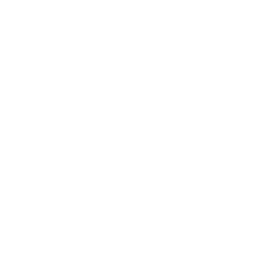
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Opetussuunnitelmien samankaltaisuusanalyysi</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Korkeakoulutus / Akateemisten ohjelmien suunnittelu &nbsp;|&nbsp; Maaliskuu 2026</p>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Higher Education / Academic Program Design &nbsp;|&nbsp; March 2026</p>
</div>
</div>
</div>

## Tiivistelmä

Tässä muistikirjassa mitataan opetussuunnitelmien päällekkäisyyttä
yliopiston kurssiluettelossa käyttäen **PROC DISTANCE** -proseduuria ja
menetelmää **METHOD=DJACCARD** — Jaccardin
*erilaisuuskerrointa*, joka on luonnollinen etäisyysmitta binääriselle
läsnäolo/poissaolo-datalle. Jokaisella kurssilla on 40 binääristä
merkintää, jotka osoittavat, mitkä akkreditoinnin oppimistulokset kurssi
kattaa, joten kahden kurssin välinen Jaccardin etäisyys on niiden
katettujen tulosten osuus, joita niillä **ei** ole yhteisenä
(0 = identtiset tulosjoukot, 1 = ei yhtään yhteistä tulosta).

Analyysi etenee kahdessa osassa. Ensin se profiloi 100 kurssin
luettelossa tulosten kattavuuden laajuutta laitoksittain (PROC MEANS, PROC FREQ,
kattavuuden laatikkokuvio) ja merkitsee oppimistulokset, joita **yksikään**
laitoksen kurssi ei kata (kattavuusaukot). Toiseksi se pureutuu
tarkennettuun 10 kurssin paneeliin, joka on koottu kahdesta määrällisesti
eniten päällekkäisestä laitoksesta — tilastotieteestä ja datatieteestä —
laskee täydellisen parittaisen Jaccardin etäisyysmatriisin ja asettaa
lähimmät kurssiparit paremmuusjärjestykseen
konsolidoinnin tarkastelun ehdokkaina. Tavoitteena on antaa opetussuunnitelma-
komitealle kaksi konkreettista tuotosta: paremmuusjärjestykseen asetettu luettelo
samankaltaisimmista kursseista sekä laitos–tulos-kohtainen aukkokartta.

## Tietolähteet

| Lähde | Kuvaus | Tietueita |
|--------|-------------|---------|
| WORK.COURSE_OUTCOMES | Binäärinen oppimistulosten kattavuus kurssia kohti (40 tulosmerkintää) | 100 |
| WORK.PANEL10 | Tilastotieteen + datatieteen konsolidointipaneeli | 10 |

Luettelo on synteettinen. Tulosmerkinnät on arvottu
laitoskohtaisilla todennäköisyyksillä siten, että tieteenalat painottavat
eri tulosklustereita (tietotekniikka ja matematiikka painottavat
varhaisia tuloksia, laboratoriotieteet painottavat keskimmäistä kaistaa), mikä antaa
etäisyysanalyysille realistisen rakenteen. Tämä ympäristö toimii ilman lisenssiä,
joten työluettelo on rajattu 100 kurssiin.

---

In [1]:
/* --------------------------------------------------------
   Luo synteettinen kurssien oppimistulosmatriisi
   500 kurssia x 40 akkreditoinnin oppimistulosta
   (lisensoimaton tila pitää ensimmäiset 100)
   -------------------------------------------------------- */
TIEDOT work.course_outcomes;
    CALL streaminit(42);
    TAULUKKO outcomes[40] lo_1 - lo_40;
    TAULUKKO dept_list[8] $15 _temporary_ ('Tietotekniikka' 'Matematiikka' 'Tilastotiede' 'Tekniikka' 'Biologia' 'Kemia' 'Fysiikka' 'Datatiede');
    TEE course_id = 1 ASTI 500;
        course_label = cat('CRS', KIRJOITA(course_id, z4.));
        dept_idx = int(rand('uniform') * 8) + 1;
        department = dept_list[dept_idx];
        /* Kurssin taso vaikuttaa tulosten laajuuteen */
        course_level = int(rand('uniform') * 4) + 1;
        level_code = course_level * 100;
        /* Laitoskohtaiset tulosklusterit */
        TEE lo = 1 ASTI 40;
            base_prob = 0.15;
            /* Laitokset 1-2 (Tietotekniikka, Matematiikka): painota tuloksia 1-15 */
            JOS dept_idx <= 2 AND lo <= 15 NIIN
                base_prob = 0.4 + course_level * 0.05;
            /* Laitokset 3-4 (Tilastotiede, Tekniikka): painota tuloksia 10-25 */
            MUUTEN JOS dept_idx SISÄLLÄ (3, 4) AND 10 <= lo <= 25 NIIN
                base_prob = 0.35 + course_level * 0.05;
            /* Laitokset 5-7 (Biologia, Kemia, Fysiikka): painota 20-35 */
            MUUTEN JOS dept_idx SISÄLLÄ (5, 6, 7) AND 20 <= lo <= 35 NIIN
                base_prob = 0.38 + course_level * 0.04;
            /* Laitos 8 (Datatiede): laaja kattavuus */
            MUUTEN JOS dept_idx = 8 NIIN
                base_prob = 0.25 + course_level * 0.03;
            outcomes[lo] = (rand('uniform') < base_prob);
        LOPPU;
        TULOSTE;
    LOPPU;
    POISTA dept_idx course_level base_prob lo;
SUORITA;


NOTE: DATA work.course_outcomes

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.course_outcomes (100 rows, 44 columns).
NOTE: DATA elapsed:
  wall  1.82 seconds
  cpu   1.82 seconds


In [2]:
/* --------------------------------------------------------
   Luo kurssiluettelon metatiedot
   -------------------------------------------------------- */
TIEDOT work.course_catalog;
    CALL streaminit(43);
    TAULUKKO dept_list[8] $15 _temporary_ ('Tietotekniikka' 'Matematiikka' 'Tilastotiede' 'Tekniikka' 'Biologia' 'Kemia' 'Fysiikka' 'Datatiede');
    TAULUKKO format_list[3] $12 _temporary_ ('Luento' 'Laboratorio' 'Seminaari');
    TEE course_id = 1 ASTI 500;
        course_label = cat('CRS-', KIRJOITA(course_id, z4.));
        dept_idx = int(rand('uniform') * 8) + 1;
        department = dept_list[dept_idx];
        level_code = (int(rand('uniform') * 4) + 1) * 100;
        credit_hours = int(rand('uniform') * 3) + 2;
        format_idx = int(rand('uniform') * 3) + 1;
        delivery_format = format_list[format_idx];
        enrollment_cap = int(rand('uniform') * 150) + 20;
        avg_enrollment = int(enrollment_cap * (rand('uniform') * 0.5 + 0.4));
        last_offered = '01JAN2025'd + int(rand('uniform') * 365);
        TULOSTE;
    LOPPU;
    POISTA dept_idx format_idx;
    MUOTO last_offered date9.;
SUORITA;


NOTE: DATA work.course_catalog

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.course_catalog (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.09 seconds
  cpu   0.09 seconds


---

                                                  The MEANS Procedure

                                               Analysis Variable : lo_1

                                                              N
                                          Laitos            Obs           Mean
                                          ------------------------------------
                                          Biologia           10      0.2000000
                                          Datatiede          14      0.1428571
                                          Fysiikka            7      0.2857143
                                          Kemia              19      0.2105263
                                          Matematiikka        9      0.6666667
                                          Tekniikka          17      0.0000000
                                          Tietotekniikka     13      0.3846154
                                          Tilastotiede       11      0.0909091
  


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_department_level_code.spec.json
NOTE: PROC FREQ statement used.


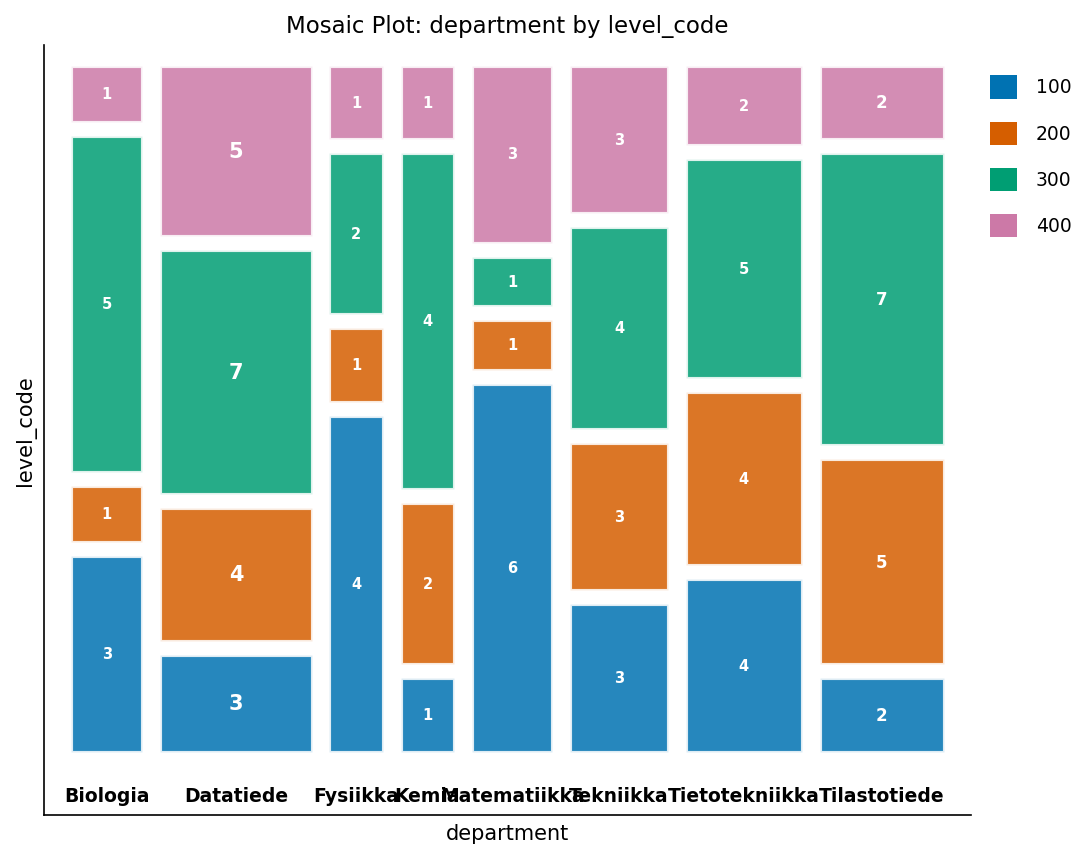

In [3]:
/* --------------------------------------------------------
   Oppimistulosten peruskattavuus laitoksittain
   -------------------------------------------------------- */
PROSEDUURI KESKIARVOT TIEDOT=work.course_outcomes mean;
    LUOKKA department;
    MUUTTUJA lo_1 - lo_40;
    NIMIKE department="Laitos";
SUORITA;

PROSEDUURI FREKVENSSIT TIEDOT=work.course_catalog;
    TABLES department * level_code / nopercent norow nocol;
    NIMIKE department="Laitos" level_code="Taso";
SUORITA;

---


NOTE: DATA work.outcome_counts


NOTE: Read 100 rows from work.course_outcomes.
NOTE: Wrote work.outcome_counts (100 rows, 45 columns).
NOTE: DATA elapsed:
  wall  0.04 seconds
  cpu   0.04 seconds
NOTE: PROC SGPLOT data=work.outcome_counts

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


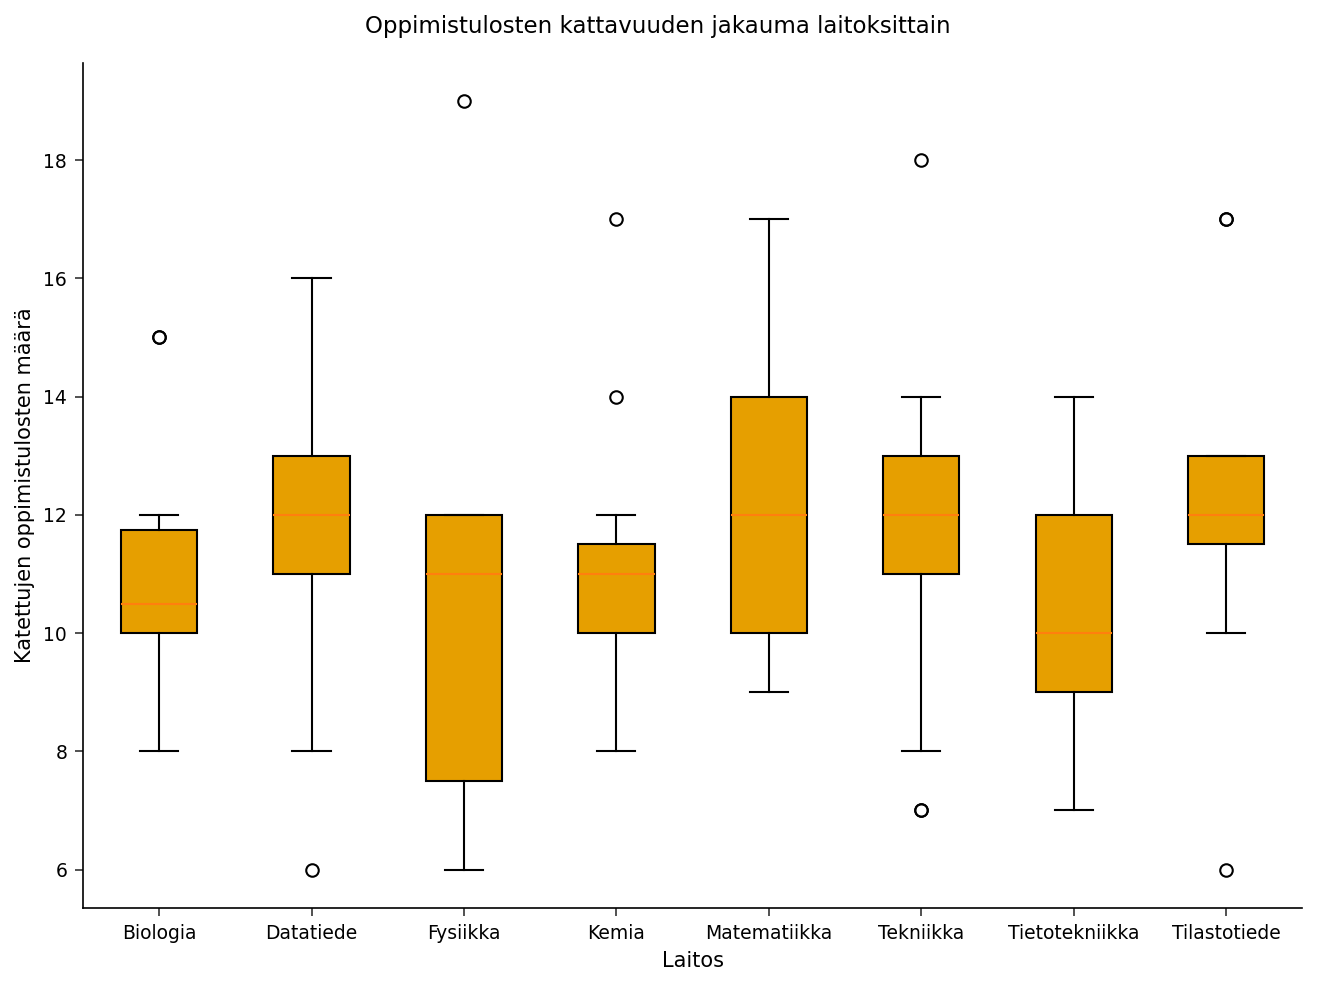

In [4]:
/* --------------------------------------------------------
   Oppimistulosten kattavuustiheys laitoksittain
   -------------------------------------------------------- */
TIEDOT work.outcome_counts;
    ASETA work.course_outcomes;
    TAULUKKO outcomes[40] lo_1 - lo_40;
    total_outcomes = sum(OF outcomes[*]);
SUORITA;

PROSEDUURI SGPLOT TIEDOT=work.outcome_counts;
    VBOX total_outcomes / category=department;
    NIMIKE department="Laitos" total_outcomes="Katettujen oppimistulosten määrä";
    YAXIS NIMIKE="Katettujen oppimistulosten määrä";
    XAXIS NIMIKE="Laitos";
    OTSIKKO "Oppimistulosten kattavuuden jakauma laitoksittain";
SUORITA;

---

In [5]:
/* --------------------------------------------------------
   Konsolidointipaneeli: ensimmäiset 10 tilastotieteen /
   datatieteen kurssia (kaksi määrällisesti eniten
   päällekkäistä laitosta). Uudelleennimeä ne P01-P10
   juoksevalla laskurilla, jotta neliömäisen OUT=-
   etäisyysmatriisin sarakkeet ovat siistit ja
   osoitettavissa, ja laske sitten täydellinen parittainen
   Jaccard-etäisyysmatriisi menetelmällä METHOD=DJACCARD
   (0 = identtiset tulosjoukot, 1 = ei yhtään yhteistä tulosta).
   -------------------------------------------------------- */
TIEDOT work.panel10;
    ASETA work.course_outcomes(MISSÄ=(department SISÄLLÄ ('Tilastotiede' 'Datatiede')));
    PIDÄ seq 0;
    seq + 1;
    JOS seq > 10 NIIN PYSÄYTÄ;
    panel_id = cat('P', KIRJOITA(seq, z2.));
    POISTA seq;
SUORITA;

PROSEDUURI TULOSTA TIEDOT=work.panel10 noobs NIMIKE;
    MUUTTUJA panel_id course_label department level_code;
    NIMIKE panel_id="Paneelin tunnus" course_label="Kurssi"
          department="Laitos" level_code="Taso";
    OTSIKKO "Konsolidointipaneeli: tilastotieteen ja datatieteen kurssit";
SUORITA;

PROSEDUURI distance TIEDOT=work.panel10
              out=work.panel_dist
              METHOD=djaccard;
    MUUTTUJA nominal(lo_1 - lo_40);
    id panel_id;
SUORITA;

PROSEDUURI TULOSTA TIEDOT=work.panel_dist noobs;
    OTSIKKO "Parittainen Jaccard-etäisyysmatriisi (10 kurssia)";
SUORITA;

                              Konsolidointipaneeli: tilastotieteen ja datatieteen kurssit                               

Paneelin tunnus   Kurssi        Laitos  Taso
P01              CRS0003  Datatiede      300
P02              CRS0006  Tilastotiede   300
P03              CRS0014  Datatiede      300
P04              CRS0015  Tilastotiede   300
P05              CRS0017  Tilastotiede   200
P06              CRS0019  Datatiede      100
P07              CRS0022  Tilastotiede   400
P08              CRS0033  Datatiede      200
P09              CRS0038  Tilastotiede   100
P10              CRS0040  Tilastotiede   100

                              Konsolidointipaneeli: tilastotieteen ja datatieteen kurssit                               

                                   Parittainen Jaccard-etäisyysmatriisi (10 kurssia)                                    

_NAME_           P01           P02           P03           P04           P05           P06           P07           P08           P09      


NOTE: DATA work.panel10


NOTE: Read 41 rows from work.course_outcomes.
NOTE: Wrote work.panel10 (10 rows, 45 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC PRINT data=work.panel10

NOTE: PROC PRINT completed: 10 observations printed, 4 variables
NOTE: PROC DISTANCE data=work.panel10 method=Djaccard

NOTE: PROC DISTANCE: 10 observations, 40 variables, method=Djaccard
NOTE: PROC PRINT data=work.panel_dist

NOTE: PROC PRINT completed: 10 observations printed, 11 variables


In [6]:
/* --------------------------------------------------------
   Muunna neliömäinen etäisyysmatriisi kurssiparien
   paremmuusjärjestykseen asetetuksi luetteloksi. OUT=-
   etäisyyssarakkeet osoitetaan nimenomaisella nimilistalla
   (P01 P02 ... P10); vain aito yläkolmio (col > row)
   säilytetään, jotta jokainen järjestämätön pari esiintyy
   kerran ja nollalävistäjä ohitetaan. Viisi lähintä paria
   ovat konsolidoinnin tarkastelun ehdokkaita.
   -------------------------------------------------------- */
TIEDOT work.similar_courses;
    ASETA work.panel_dist;
    TAULUKKO d[10] P01 P02 P03 P04 P05 P06 P07 P08 P09 P10;
    PITUUS course_a course_b $8;
    course_a = _name_;
    row + 1;
    TEE col = 1 ASTI 10;
        JOS col > row NIIN TEE;
            course_b     = vname(d[col]);
            jaccard_dist = round(d[col], 0.001);
            TULOSTE;
        LOPPU;
    LOPPU;
    SÄILYTÄ course_a course_b jaccard_dist;
SUORITA;

PROSEDUURI KESKIARVOT TIEDOT=work.similar_courses n MIN q1 MEDIAN mean MAX maxdec=3;
    MUUTTUJA jaccard_dist;
    NIMIKE jaccard_dist="Jaccard-etäisyys";
    OTSIKKO "Parittaisten Jaccard-etäisyyksien jakauma (45 kurssiparia)";
SUORITA;

PROSEDUURI LAJITTELE TIEDOT=work.similar_courses; MUKAAN jaccard_dist; SUORITA;

TIEDOT work.top_pairs;
    ASETA work.similar_courses;
    pair_rank = _n_;
    JOS pair_rank <= 5;
SUORITA;

PROSEDUURI TULOSTA TIEDOT=work.top_pairs noobs NIMIKE;
    MUUTTUJA pair_rank course_a course_b jaccard_dist;
    NIMIKE pair_rank="Sija" course_a="Kurssi A"
          course_b="Kurssi B" jaccard_dist="Jaccard-etäisyys";
    OTSIKKO "Viisi lähintä kurssiparia (yhdistämisehdokkaat)";
SUORITA;

                               Parittaisten Jaccard-etäisyyksien jakauma (45 kurssiparia)                               

                                                  The MEANS Procedure

 Variable      Label                    N     Minimum   Lower Quartile      Median        Mean     Maximum
 ---------------------------------------------------------------------------------------------------------
 jaccard_dist  Jaccard-etäisyys        45       0.588            0.762       0.826       0.818       0.962
 ---------------------------------------------------------------------------------------------------------

                                    Viisi lähintä kurssiparia (yhdistämisehdokkaat)                                     

Sija  Kurssi A  Kurssi B   Jaccard-etäisyys
   1  P02       P10                   0.588
   2  P03       P04                     0.6
   3  P03       P05                   0.667
   4  P02       P04                   0.684
   5  P02       P07                 


NOTE: DATA work.similar_courses


NOTE: Read 10 rows from work.panel_dist.
NOTE: Wrote work.similar_courses (45 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: PROC SORT data=work.similar_courses

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 45 rows from work.similar_courses.
NOTE: Wrote work.similar_courses (45 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.top_pairs


NOTE: Read 45 rows from work.similar_courses.
NOTE: Wrote work.top_pairs (5 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.top_pairs

NOTE: PROC PRINT completed: 5 observations printed, 4 variables


                                      Kattamattomat oppimistulokset laitoksittain                                       

                                                   The FREQ Procedure

Laitos            Frequency    Percent
---------------------------------------
Biologia                  8     26.67
Fysiikka                  8     26.67
Kemia                     2      6.67
Matematiikka              4     13.33
Tekniikka                 2      6.67
Tietotekniikka            3     10.00
Tilastotiede              3     10.00
                                     Otos kattavuusaukoista (12 ensimmäistä 30:stä)                                     

  Laitos  Kattamaton oppimistulos
Biologia  LO02
Biologia  LO10
Biologia  LO15
Biologia  LO16
Biologia  LO17
Biologia  LO18
Biologia  LO36
Biologia  LO37
Fysiikka  LO02
Fysiikka  LO03
Fysiikka  LO07
Fysiikka  LO10

... 18 more observations (showing 12 of 30)




NOTE: PROC MEANS
NOTE: Output dataset work.dept_coverage has 8 observations and 43 variables.
NOTE: PROC MEANS statement used.
NOTE: DATA work.outcome_gaps


NOTE: Read 8 rows from work.dept_coverage.
NOTE: Wrote work.outcome_gaps (30 rows, 4 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_department.spec.json
NOTE: PROC FREQ statement used.
NOTE: PROC PRINT data=work.outcome_gaps

NOTE: PROC PRINT completed: 12 observations printed, 2 variables


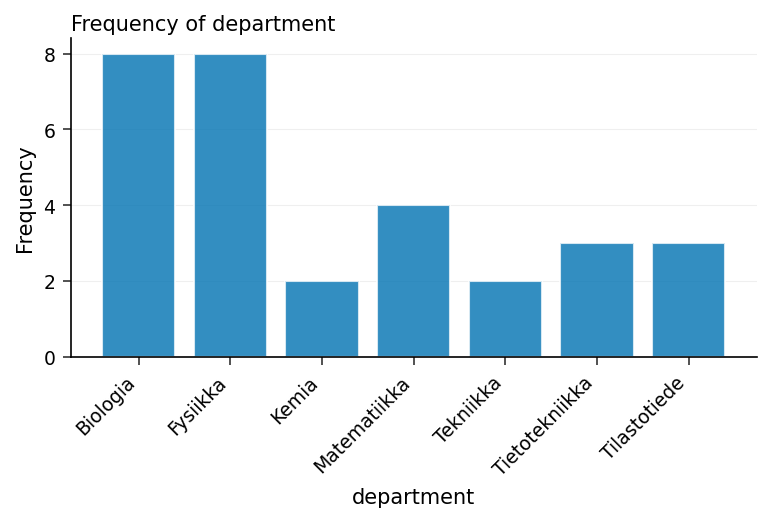

In [7]:
/* --------------------------------------------------------
   Kattavuusaukot: oppimistulokset, joita EI YKSIKÄÄN
   laitoksen kurssi kata. PROC MEANS summaa kunkin
   binäärisen tulosmerkinnän laitoksen sisällä; nollasumma
   tarkoittaa, että tulos puuttuu kyseisen laitoksen
   luettelosta.
   -------------------------------------------------------- */
PROSEDUURI KESKIARVOT TIEDOT=work.course_outcomes sum NOPRINT;
    LUOKKA department;
    MUUTTUJA lo_1 - lo_40;
    TULOSTE out=work.dept_coverage(MISSÄ=(_type_=1))
        sum=lo_1 - lo_40;
SUORITA;

TIEDOT work.outcome_gaps;
    ASETA work.dept_coverage;
    TAULUKKO outcomes[40] lo_1 - lo_40;
    TEE lo = 1 ASTI 40;
        outcome_id = cat('LO', KIRJOITA(lo, z2.));
        courses_covering = outcomes[lo];
        JOS courses_covering = 0 NIIN TEE;
            gap_flag = 1;
            TULOSTE;
        LOPPU;
    LOPPU;
    SÄILYTÄ department outcome_id courses_covering gap_flag;
SUORITA;

PROSEDUURI FREKVENSSIT TIEDOT=work.outcome_gaps;
    TABLES department / nocum;
    NIMIKE department="Laitos";
    OTSIKKO "Kattamattomat oppimistulokset laitoksittain";
SUORITA;

PROSEDUURI TULOSTA TIEDOT=work.outcome_gaps(obs=12) noobs NIMIKE;
    MUUTTUJA department outcome_id;
    NIMIKE department="Laitos" outcome_id="Kattamaton oppimistulos";
    OTSIKKO "Otos kattavuusaukoista (12 ensimmäistä 30:stä)";
SUORITA;

---

### Tulkinta

**Konsolidointipaneeli.** 10 kurssin tilastotieteen / datatieteen
paneelin 45 järjestämättömän parin joukossa Jaccardin etäisyys vaihtelee
välillä 0.588–0.962 mediaanin ollessa 0.826 (keskiarvo 0.818). Lähin
pari on P02 ja P10 etäisyydellä 0.588, joita seuraavat
P03–P04 etäisyydellä 0.600 ja P03–P05 etäisyydellä 0.667. Jopa
samankaltaisimmat kurssit eroavat silti noin 59 %:ssa katetuista
tuloksistaan, joten tämä luettelo ei sisällä **yhtään lähes päällekkäistä kurssia** — ei
ole yhtään paria, jonka komitea voisi yhdistää suoraan. Paremmuusjärjestykseen asetettu luettelo sen sijaan
osoittaa ne muutamat parit, joita kannattaa verrata manuaalisesti opetussuunnitelmatasolla ennen
seuraavaa luettelokierrosta; suurimman etäisyyden parit (lähellä 0.962) vahvistavat,
että tilastotieteen ja datatieteen kurssit kattavat aidosti erilaiset tulosjoukot
jaetusta laitosnaapuruudesta huolimatta.

**Kattavuusaukot.** Kolmekymmentä laitos–tulos-kohtaista aukkoa nousee esiin
luettelosta. Laboratoriopainotteiset tieteenalat kantavat niistä eniten: **biologia** ja
**fysiikka** jättävät kumpikin 8 kattamatta 40:stä akkreditointituloksesta,
joita seuraa **matematiikka** (4). Määrälliset laitokset ovat
parhaiten katettuja — **kemia** ja **tekniikka** jättävät kattamatta vain 2 tulosta
kumpikin. Nämä aukot ovat luonnollisia kohteita uusien kurssien kehittämiselle tai
ristiinlistaukselle: koko laitokselta puuttuva tulos on kattavuus-
riski akkreditoinnin uusinnassa, kun taas konsolidointiluettelo käsittelee
päinvastaista päällekkäisen työn ongelmaa. Yhdessä nämä kaksi tuotosta antavat
komitealle mahdollisuuden tiukentaa luetteloa molemmista päistä — karsimalla päällekkäisyyttä
ja täyttämällä aukkoja — käyttäen yhtä joukkopohjaista etäisyysmittaa.

---

In [8]:
/* --------------------------------------------------------
   Vie paremmuusjärjestykseen asetetut yhdistämisehdokkaat ja
   laitosten tulosaukkokartta opetussuunnitelmakomitealle.
   -------------------------------------------------------- */
PROSEDUURI VIE TIEDOT=work.similar_courses
    OUTFILE='curriculum_consolidation_candidates.csv'
    DBMS=csv REPLACE;
SUORITA;

PROSEDUURI VIE TIEDOT=work.outcome_gaps
    OUTFILE='curriculum_outcome_gaps.csv'
    DBMS=csv REPLACE;
SUORITA;


NOTE: PROC EXPORT data=work.similar_courses outfile=curriculum_consolidation_candidates.csv

NOTE: Exported 45 rows to curriculum_consolidation_candidates.csv.
NOTE: PROC EXPORT data=work.outcome_gaps outfile=curriculum_outcome_gaps.csv

NOTE: Exported 30 rows to curriculum_outcome_gaps.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Luottamuksellinen
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Toteutettu <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>-alustalla
</div>
</div>